In [31]:
# ======================================================
# STEP 1: Communication simulation for three penetration levels
# ======================================================

import random
import statistics
import uuid
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np

# ------------------------------------------------------
# Reproducibility
# ------------------------------------------------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ------------------------------------------------------
# Scenario settings
# ------------------------------------------------------
penetration_scenarios = {
    0.20: {
        "label": "20%",
        "num_evs": 10,
        "bandwidth_bps": 10_000_000,
        "base_propagation_ms": 8.0,
        "jitter_ms_std": 2.0,
        "packet_loss_prob": 0.005
    },
    0.60: {
        "label": "60%",
        "num_evs": 30,
        "bandwidth_bps": 8_000_000,
        "base_propagation_ms": 10.0,
        "jitter_ms_std": 3.0,
        "packet_loss_prob": 0.015
    },
    1.00: {
        "label": "100%",
        "num_evs": 50,
        "bandwidth_bps": 6_000_000,
        "base_propagation_ms": 14.0,
        "jitter_ms_std": 4.5,
        "packet_loss_prob": 0.030
    }
}

# ------------------------------------------------------
# Common communication parameters
# ------------------------------------------------------
EVCC_PROCESSING_MS = 4.0
SECC_PROCESSING_MS = 6.0
MAX_RETRIES = 2

messages_per_session = [
    "SessionSetupReq",
    "ServiceDiscoveryReq",
    "ChargeParameterDiscoveryReq",
    "PowerDeliveryReq",
    "CurrentDemandReq",
    "CurrentDemandReq",
    "CurrentDemandReq",
    "SessionStopReq",
]

ev_battery_types = [40.0, 60.0, 80.5, 100.0]

# ------------------------------------------------------
# Data structure
# ------------------------------------------------------
@dataclass
class MessageRecord:
    penetration: str
    session_id: str
    ev_id: str
    message_type: str
    direction: str
    payload_bytes: int
    tx_attempts: int
    success: bool
    serialization_ms: float
    propagation_ms: float
    processing_ms: float
    e2e_delay_ms: float


# ------------------------------------------------------
# XML message builder
# ------------------------------------------------------
def build_xml_message(message_type: str, ev_id: str, evse_id: str,
                      battery_kwh: float, soc_percent: float,
                      requested_power_kw: float) -> str:
    root = ET.Element("V2G_Message")

    header = ET.SubElement(root, "Header")
    ET.SubElement(header, "SessionID").text = str(uuid.uuid4())
    ET.SubElement(header, "MessageType").text = message_type

    body = ET.SubElement(root, "Body")
    ET.SubElement(body, "EVCCID").text = ev_id
    ET.SubElement(body, "SECCID").text = evse_id
    ET.SubElement(body, "BatteryCapacity_kWh").text = f"{battery_kwh:.1f}"
    ET.SubElement(body, "ArrivalSOC_pct").text = f"{soc_percent:.1f}"
    ET.SubElement(body, "RequestedPower_kW").text = f"{requested_power_kw:.2f}"

    return ET.tostring(root, encoding="utf-8").decode("utf-8")


# ------------------------------------------------------
# Message transfer simulator
# ------------------------------------------------------
def simulate_message_transfer(
    penetration_label: str,
    session_id: str,
    ev_id: str,
    message_type: str,
    direction: str,
    xml_payload: str,
    bandwidth_bps: float,
    base_propagation_ms: float,
    jitter_ms_std: float,
    receiver_processing_ms: float,
    packet_loss_prob: float,
    max_retries: int,
) -> MessageRecord:

    payload_bytes = len(xml_payload.encode("utf-8"))
    serialization_ms = (payload_bytes * 8 / bandwidth_bps) * 1000.0

    attempts = 0
    success = False
    propagation_ms = 0.0
    processing_ms = receiver_processing_ms
    e2e_delay_ms = 0.0

    while attempts <= max_retries:
        attempts += 1

        jitter = random.gauss(0.0, jitter_ms_std)
        propagation_ms = max(0.1, base_propagation_ms + jitter)

        if random.random() < packet_loss_prob:
            continue

        success = True
        e2e_delay_ms = serialization_ms + propagation_ms + processing_ms
        break

    return MessageRecord(
        penetration=penetration_label,
        session_id=session_id,
        ev_id=ev_id,
        message_type=message_type,
        direction=direction,
        payload_bytes=payload_bytes,
        tx_attempts=attempts,
        success=success,
        serialization_ms=round(serialization_ms, 4),
        propagation_ms=round(propagation_ms, 4),
        processing_ms=round(processing_ms, 4),
        e2e_delay_ms=round(e2e_delay_ms, 4),
    )


# ------------------------------------------------------
# Session simulator
# ------------------------------------------------------
def simulate_session(penetration_label: str, session_idx: int, cfg: Dict) -> Tuple[List[MessageRecord], bool]:
    session_id = f"{penetration_label}_session_{session_idx:03d}"
    ev_id = f"{penetration_label}_EV_{session_idx:03d}"
    evse_id = "EVSE_A01"

    battery_kwh = random.choice(ev_battery_types)
    soc_percent = random.uniform(20.0, 60.0)
    requested_power_kw = random.uniform(3.6, 7.4)

    records: List[MessageRecord] = []

    for msg_type in messages_per_session:
        xml_req = build_xml_message(
            message_type=msg_type,
            ev_id=ev_id,
            evse_id=evse_id,
            battery_kwh=battery_kwh,
            soc_percent=soc_percent,
            requested_power_kw=requested_power_kw
        )

        req = simulate_message_transfer(
            penetration_label=penetration_label,
            session_id=session_id,
            ev_id=ev_id,
            message_type=msg_type,
            direction="EVCC->SECC",
            xml_payload=xml_req,
            bandwidth_bps=cfg["bandwidth_bps"],
            base_propagation_ms=cfg["base_propagation_ms"],
            jitter_ms_std=cfg["jitter_ms_std"],
            receiver_processing_ms=SECC_PROCESSING_MS,
            packet_loss_prob=cfg["packet_loss_prob"],
            max_retries=MAX_RETRIES
        )
        records.append(req)

        if not req.success:
            return records, False

        xml_res = build_xml_message(
            message_type=msg_type.replace("Req", "Res"),
            ev_id=ev_id,
            evse_id=evse_id,
            battery_kwh=battery_kwh,
            soc_percent=soc_percent,
            requested_power_kw=requested_power_kw
        )

        res = simulate_message_transfer(
            penetration_label=penetration_label,
            session_id=session_id,
            ev_id=ev_id,
            message_type=msg_type.replace("Req", "Res"),
            direction="SECC->EVCC",
            xml_payload=xml_res,
            bandwidth_bps=cfg["bandwidth_bps"],
            base_propagation_ms=cfg["base_propagation_ms"],
            jitter_ms_std=cfg["jitter_ms_std"],
            receiver_processing_ms=EVCC_PROCESSING_MS,
            packet_loss_prob=cfg["packet_loss_prob"],
            max_retries=MAX_RETRIES
        )
        records.append(res)

        if not res.success:
            return records, False

    return records, True


# ------------------------------------------------------
# Metric helper
# ------------------------------------------------------
def percentile(values: List[float], p: float) -> float:
    if not values:
        return 0.0
    values = sorted(values)
    idx = int(round((len(values) - 1) * p / 100.0))
    return values[idx]


def compute_metrics(records: List[MessageRecord], session_success_flags: List[bool]) -> Dict:
    successful_msgs = [r for r in records if r.success]
    all_delays = [r.e2e_delay_ms for r in successful_msgs]
    all_payloads = [r.payload_bytes for r in successful_msgs]

    total_msgs = len(records)
    lost_msgs = len([r for r in records if not r.success])
    packet_loss_rate = lost_msgs / total_msgs if total_msgs else 0.0
    session_success_rate = sum(session_success_flags) / len(session_success_flags) if session_success_flags else 0.0

    avg_delay = statistics.mean(all_delays) if all_delays else 0.0
    min_delay = min(all_delays) if all_delays else 0.0
    max_delay = max(all_delays) if all_delays else 0.0
    p95_delay = percentile(all_delays, 95)

    jitter_vals = [abs(all_delays[i] - all_delays[i - 1]) for i in range(1, len(all_delays))]
    avg_jitter = statistics.mean(jitter_vals) if jitter_vals else 0.0

    total_bytes = sum(all_payloads)
    total_time_s = sum(all_delays) / 1000.0 if all_delays else 0.0
    throughput_bps = (total_bytes * 8 / total_time_s) if total_time_s > 0 else 0.0

    useful_msgs = [r for r in successful_msgs if r.message_type.endswith("Res")]
    useful_bytes = sum(r.payload_bytes for r in useful_msgs)
    goodput_bps = (useful_bytes * 8 / total_time_s) if total_time_s > 0 else 0.0

    avg_retries = statistics.mean([r.tx_attempts - 1 for r in records]) if records else 0.0

    return {
        "total_messages": total_msgs,
        "successful_messages": len(successful_msgs),
        "lost_messages": lost_msgs,
        "packet_loss_rate": packet_loss_rate,
        "session_success_rate": session_success_rate,
        "avg_e2e_delay_ms": avg_delay,
        "min_e2e_delay_ms": min_delay,
        "max_e2e_delay_ms": max_delay,
        "p95_e2e_delay_ms": p95_delay,
        "avg_jitter_ms": avg_jitter,
        "throughput_bps": throughput_bps,
        "goodput_bps": goodput_bps,
        "avg_retries": avg_retries,
    }


# ------------------------------------------------------
# Run all scenarios
# ------------------------------------------------------
all_records = []
scenario_metrics = []

for pen, cfg in penetration_scenarios.items():
    label = cfg["label"]
    session_success_flags = []
    scenario_records = []

    for s in range(1, cfg["num_evs"] + 1):
        recs, ok = simulate_session(label, s, cfg)
        scenario_records.extend(recs)
        session_success_flags.append(ok)

    metrics = compute_metrics(scenario_records, session_success_flags)
    metrics["penetration"] = label

    scenario_metrics.append(metrics)
    all_records.extend(scenario_records)

metrics_df = pd.DataFrame(scenario_metrics)
records_df = pd.DataFrame([asdict(r) for r in all_records])

print("Communication simulation completed successfully.")
print("\nScenario metrics:")
print(metrics_df)

Communication simulation completed successfully.

Scenario metrics:
   total_messages  successful_messages  lost_messages  packet_loss_rate  \
0             160                  160              0               0.0   
1             480                  480              0               0.0   
2             800                  800              0               0.0   

   session_success_rate  avg_e2e_delay_ms  min_e2e_delay_ms  max_e2e_delay_ms  \
0                   1.0         13.387417            7.1696           21.5003   
1                   1.0         15.435331            7.3305           24.1208   
2                   1.0         19.556530            5.3824           34.6979   

   p95_e2e_delay_ms  avg_jitter_ms  throughput_bps    goodput_bps  \
0           17.4776       2.923087   202981.652500  101490.826250   
1           20.5127       3.887969   176102.475072   88051.237536   
2           27.0037       5.467572   139376.466698   69688.233349   

   avg_retries penetration  


In [32]:
# ======================================================
# STEP 2: Save communication results
# ======================================================

import os  # <-- add this line

OUTPUT_FOLDER = "/Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

metrics_file = os.path.join(OUTPUT_FOLDER, "comm_metrics_by_penetration.csv")
records_file = os.path.join(OUTPUT_FOLDER, "comm_message_records_by_penetration.csv")

metrics_df.to_csv(metrics_file, index=False)
records_df.to_csv(records_file, index=False)

print("Saved metrics to:", metrics_file)
print("Saved records to:", records_file)

Saved metrics to: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/comm_metrics_by_penetration.csv
Saved records to: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/comm_message_records_by_penetration.csv


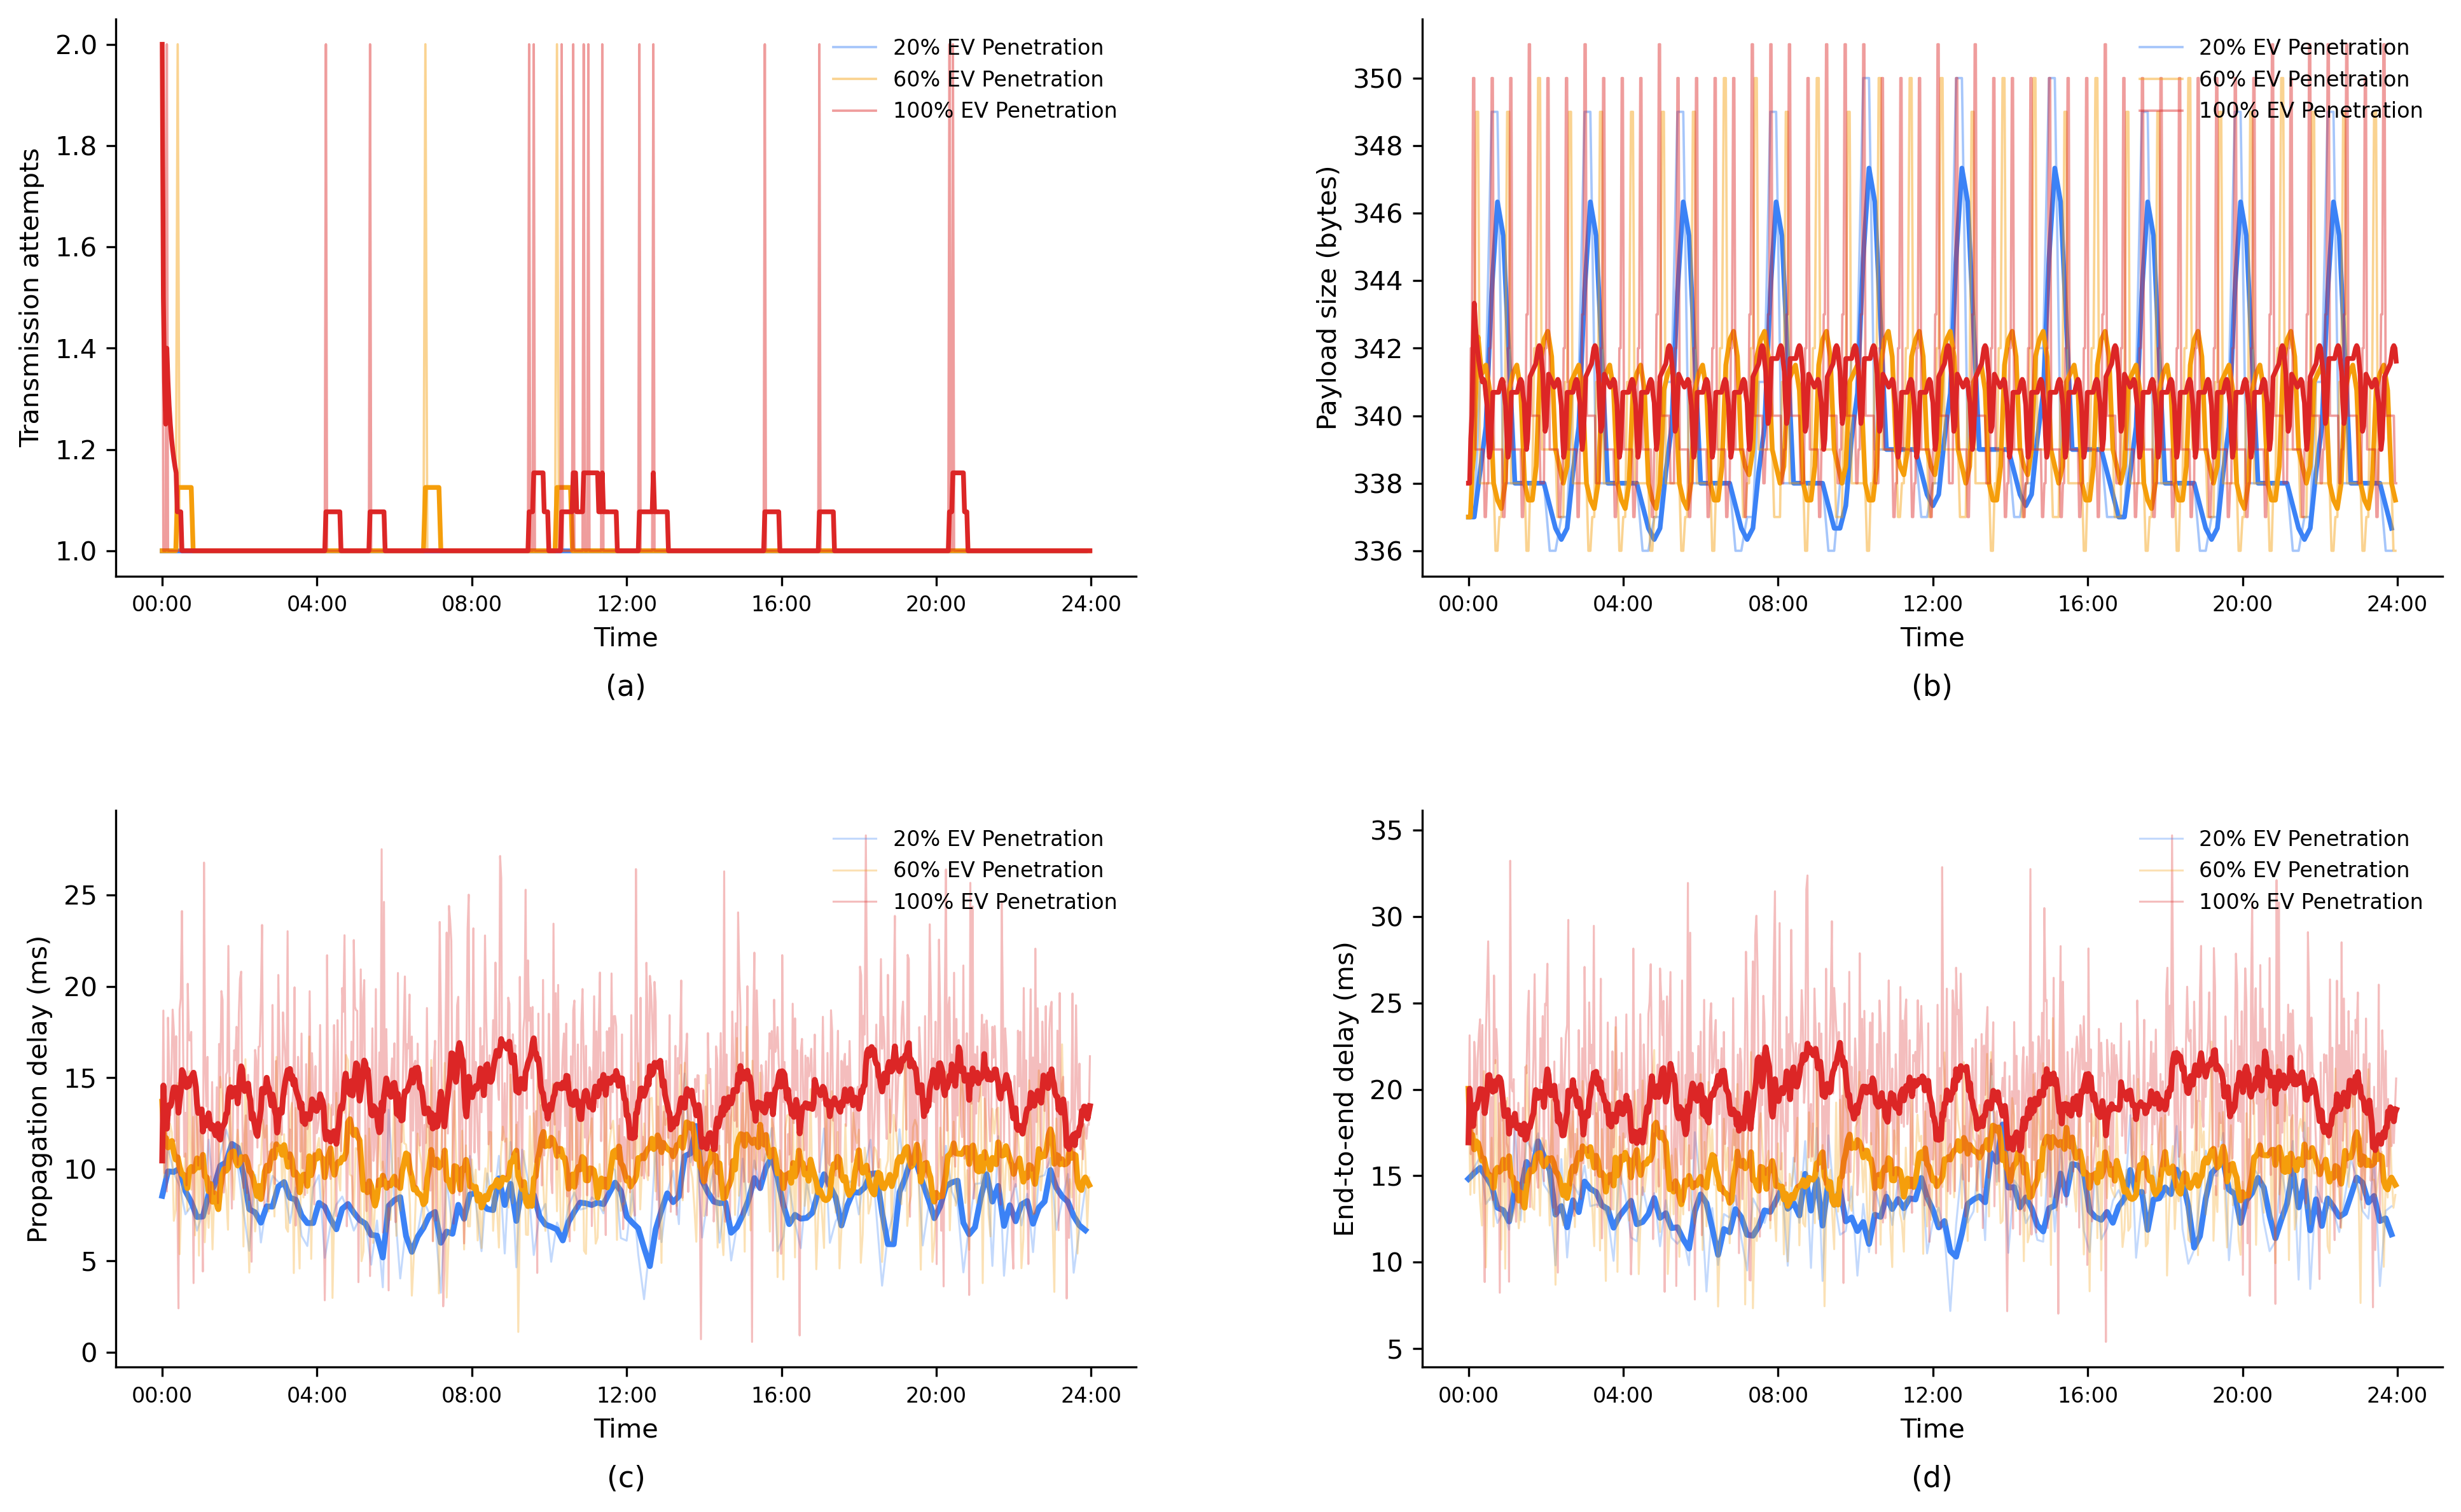

In [33]:
# ======================================================
# Congested temporal communication plots (balanced visibility)
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

OUTPUT_FOLDER = "/Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

PLOT_FILE = os.path.join(OUTPUT_FOLDER, "communication_temporal_congested.png")

plot_records = records_df.copy()

# ------------------------------------------------------
# Time mapping
# ------------------------------------------------------
plot_records["MsgIndex"] = plot_records.groupby("penetration").cumcount()
plot_records["TotalMsgsPen"] = plot_records.groupby("penetration")["MsgIndex"].transform("max") + 1

plot_records["TimeHour"] = (
    plot_records["MsgIndex"] / plot_records["TotalMsgsPen"] * 24.0
)

# ------------------------------------------------------
# Setup
# ------------------------------------------------------
penetrations = ["20%", "60%", "100%"]

pen_colors = {
    "20%": "#3B82F6",
    "60%": "#F59E0B",
    "100%": "#DC2626"
}

tick_positions = np.arange(0, 25, 4)
tick_labels = ["00:00", "04:00", "08:00", "12:00", "16:00", "20:00", "24:00"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=300)
axes = axes.flatten()

# ✅ Swapped (c) and (d)
plot_settings = [
    ("tx_attempts", "Transmission attempts", "(a)", False),
    ("payload_bytes", "Payload size (bytes)", "(b)", False),
    ("propagation_ms", "Propagation delay (ms)", "(c)", True),
    ("e2e_delay_ms", "End-to-end delay (ms)", "(d)", True)
]

# ------------------------------------------------------
# Plot
# ------------------------------------------------------
for ax, (metric, ylabel, label, is_delay) in zip(axes, plot_settings):

    for pen in penetrations:
        sub = plot_records[plot_records["penetration"] == pen].copy()

        ax.plot(
            sub["TimeHour"],
            sub[metric],
            color=pen_colors[pen],
            linewidth=0.75 if is_delay else 0.9,
            alpha=0.30 if is_delay else 0.45,
            label=f"{pen} EV Penetration"
        )

        window = max(3, len(sub) // 60)
        smooth = sub[metric].rolling(window=window, min_periods=1).mean()

        ax.plot(
            sub["TimeHour"],
            smooth,
            color=pen_colors[pen],
            linewidth=2.2 if is_delay else 1.8,
            alpha=1.0
        )

    ax.set_xlabel("Time")
    ax.set_ylabel(ylabel)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=8)

    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        0.5, -0.20, label,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=11
    )

# Legend per subplot
for ax in axes:
    ax.legend(frameon=False, fontsize=8, loc="upper right")

plt.tight_layout()
plt.subplots_adjust(hspace=0.42, wspace=0.28)

plt.savefig(PLOT_FILE, dpi=300, bbox_inches="tight")
plt.show()